In [29]:
import numpy as np
import pandas as pd
from cyvcf2 import VCF
import os
from scipy import stats
from qqman import qqman
import matplotlib.pyplot as plt

phenotype_file = "~/public/ps3/ps3_gwas.phen"
vcf_file = os.path.expanduser("~/public/ps3/ps3_gwas.vcf.gz")
covar_file = "/home/sgaywala/ps3-wi26/ps3_gwas.eigenvec"
covar_file = os.path.expanduser(covar_file)
covar_df = pd.read_csv(covar_file, delim_whitespace=True, header=None)
covariate_matrix = covar_df.iloc[:, 2:].values

In [6]:
def gwas_linear(G, y):
    """
    G: (n_samples, n_snps)
    y: (n_samples,)
    Returns: beta, pvals
    """
    n = G.shape[0]

    # Center variables (important!)
    G_centered = G - G.mean(axis=0)
    y_centered = y - y.mean()

    # Compute beta for each SNP
    numerator = np.sum(G_centered * y_centered[:, None], axis=0)
    denominator = np.sum(G_centered**2, axis=0)
    beta = numerator / denominator

    # Predicted values
    y_hat = G_centered * beta

    # Residual variance
    rss = np.sum((y_centered[:, None] - y_hat)**2, axis=0)
    sigma2 = rss / (n - 2)

    # Standard error
    se = np.sqrt(sigma2 / denominator)

    # t-statistic
    t_stat = beta / se

    # Two-sided p-value
    pvals = 2 * stats.t.sf(np.abs(t_stat), df=n-2)

    return beta, pvals

In [7]:
def gwas_fxn(vcf_file: str, phenotype_file: str):
    vcf = VCF(vcf_file)
    
    # read phenotypes
    phen_df = pd.read_csv(phenotype_file, delim_whitespace=True, header=None)
    phen_df.columns = ["FID", "IID", "PHENO"]
    
    # read genotypes
    sample_ids = np.array(vcf.samples)
    n_samples = len(sample_ids)
    print("Number of individuals in VCF:", n_samples)
    
    genotypes = []
    chroms = []
    positions = []

    for variant in vcf:
        # variant.genotypes gives [ [0,1,True], ... ]
        # first two entries are alleles
        gt = np.array([g[0] + g[1] if g[0] != -1 else np.nan 
                       for g in variant.genotypes])
        genotypes.append(gt)
        chroms.append(variant.CHROM)
        positions.append(variant.POS)

    G = np.array(genotypes).T  # transpose to get individuals x SNPs
    
    print("# individuals x # SNPs")
    print(G.shape) # individuals x SNPs
    
    # Align Phenotypes
    phenotypes = phen_df["PHENO"].values
    phenotype_ids = phen_df["IID"].values
    id_to_pheno = dict(zip(phenotype_ids, phenotypes))

    aligned_phenotypes = np.array([id_to_pheno[s] for s in sample_ids])
    
    beta, pvals = gwas_linear(G, aligned_phenotypes)
    
    assoc_df = pd.DataFrame({
        "CHR": chroms,
        "BP": positions,
        "BETA": beta,
        "P": pvals
    })
    assoc_df["CHR"] = pd.to_numeric(assoc_df["CHR"], errors="coerce")
    assoc_df = assoc_df.sort_values(["CHR", "BP"]).reset_index(drop=True)

    print(assoc_df.head())
    
    fig, (ax0, ax1) = plt.subplots(1, 2, gridspec_kw={'width_ratios': [2, 1]})
    fig.set_size_inches((15, 5))
    qqman.manhattan(assoc_df, ax=ax0)
    qqman.qqplot(assoc_df, ax=ax1)
    

Number of individuals in VCF: 207
# individuals x # SNPs
(207, 917845)
   CHR      BP      BETA             P
0    1  752566 -0.302728  5.049645e-04
1    1  752721 -0.407888  9.056280e-07
2    1  776546 -0.462037  4.919576e-04
3    1  798959  0.296714  4.859662e-04
4    1  800007 -0.570414  9.751824e-03
[WARNING]: Column 'SNP' not found!


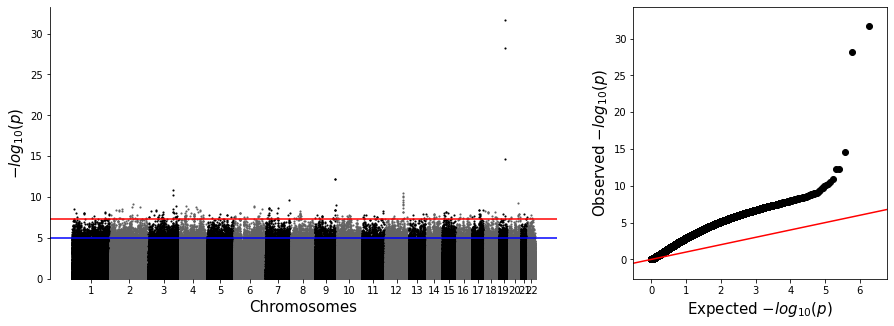

In [8]:
gwas_fxn(vcf_file,phenotype_file)

In [24]:
def gwas_linear_cov(G, y, C):
    """
    G: (n_samples, n_snps)
    y: (n_samples,)
    C: (n_samples, n_covariates)

    Returns:
        beta (n_snps,)
        pvals (n_snps,)
    """

    n = G.shape[0]

    # Add intercept to covariates
    C = np.column_stack((np.ones(n), C))

    # Precompute projection matrix components
    CtC_inv = np.linalg.inv(C.T @ C)
    P = C @ CtC_inv @ C.T   # projection onto covariates

    # Residualize phenotype
    y_res = y - P @ y

    # Residualize genotypes
    G_res = G - P @ G

    # Now run simple regression on residuals
    numerator = np.sum(G_res * y_res[:, None], axis=0)
    denominator = np.sum(G_res**2, axis=0)
    beta = numerator / denominator

    # Residual variance
    y_hat = G_res * beta
    rss = np.sum((y_res[:, None] - y_hat)**2, axis=0)

    df = n - C.shape[1] - 1
    sigma2 = rss / df

    se = np.sqrt(sigma2 / denominator)

    t_stat = beta / se
    pvals = 2 * stats.t.sf(np.abs(t_stat), df=df)

    return beta, pvals

In [25]:
def gwas_fxn_cov(vcf_file: str, phenotype_file: str, covariate_matrix):
    vcf = VCF(vcf_file)
    
    # read phenotypes
    phen_df = pd.read_csv(phenotype_file, delim_whitespace=True, header=None)
    phen_df.columns = ["FID", "IID", "PHENO"]
    
    # read genotypes
    sample_ids = np.array(vcf.samples)
    n_samples = len(sample_ids)
    print("Number of individuals in VCF:", n_samples)
    
    genotypes = []
    chroms = []
    positions = []

    for variant in vcf:
        # variant.genotypes gives [ [0,1,True], ... ]
        # first two entries are alleles
        gt = np.array([g[0] + g[1] if g[0] != -1 else np.nan 
                       for g in variant.genotypes])
        genotypes.append(gt)
        chroms.append(variant.CHROM)
        positions.append(variant.POS)

    G = np.array(genotypes).T  # transpose to get individuals x SNPs
    
    print("# individuals x # SNPs")
    print(G.shape) # individuals x SNPs
    
    # Align Phenotypes
    phenotypes = phen_df["PHENO"].values
    phenotype_ids = phen_df["IID"].values
    id_to_pheno = dict(zip(phenotype_ids, phenotypes))

    aligned_phenotypes = np.array([id_to_pheno[s] for s in sample_ids])
    
    beta, pvals = gwas_linear(G, aligned_phenotypes, covariate_matrix)
    
    assoc_df = pd.DataFrame({
        "CHR": chroms,
        "BP": positions,
        "BETA": beta,
        "P": pvals
    })
    assoc_df["CHR"] = pd.to_numeric(assoc_df["CHR"], errors="coerce")
    assoc_df = assoc_df.sort_values(["CHR", "BP"]).reset_index(drop=True)

    print(assoc_df.head())
    
    fig, (ax0, ax1) = plt.subplots(1, 2, gridspec_kw={'width_ratios': [2, 1]})
    fig.set_size_inches((15, 5))
    qqman.manhattan(assoc_df, ax=ax0)
    qqman.qqplot(assoc_df, ax=ax1)

Number of individuals in VCF: 207
# individuals x # SNPs
(207, 917845)
   CHR      BP      BETA         P
0    1  752566 -0.054095  0.610764
1    1  752721 -0.218377  0.061953
2    1  776546 -0.162870  0.275370
3    1  798959 -0.026703  0.824523
4    1  800007 -0.222533  0.316102
[WARNING]: Column 'SNP' not found!


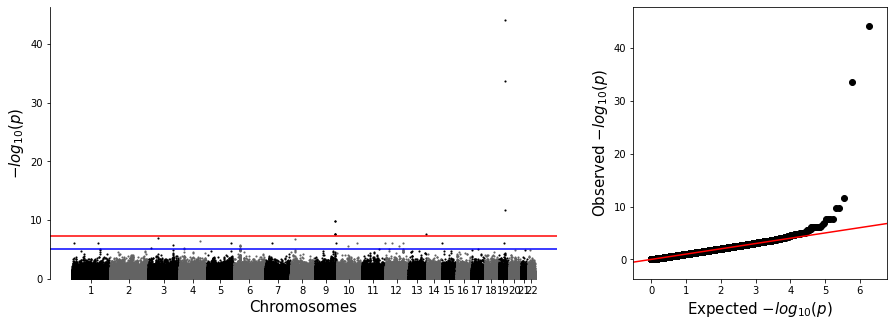

In [26]:
gwas_fxn_cov(vcf_file,phenotype_file,covariate_matrix)